# Лабораторная работа №3: Бинаризация и выделение границ на изображениях
**Цель работы:**
1. Исследование методов глобальной бинаризации (фиксированный порог, метод последовательных приближений, метод Оцу).
2. Применение адаптивной бинаризации для изображений со сложным фоном.
3. Очистка шума и морфологическое выделение внутренних и внешних границ силуэта (`sar_0.jpg`).
4. Детектирование границ дифференциальными операторами (Собель, Лапласиан) и алгоритмом Кэнни.
5. Выделение прямых линий с помощью преобразования Хафа (`img_1.jpg` и `sar_3.jpg`).

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 6)

## 1. Загрузка исходных изображений

* `sar_0.jpg` - бинарный зашумленный силуэт;
* `sar_2.jpg` - радиолокационный снимок реки;
* `sar_3.jpg` - аэродром;
* `img_1.jpg` - шахматная доска;

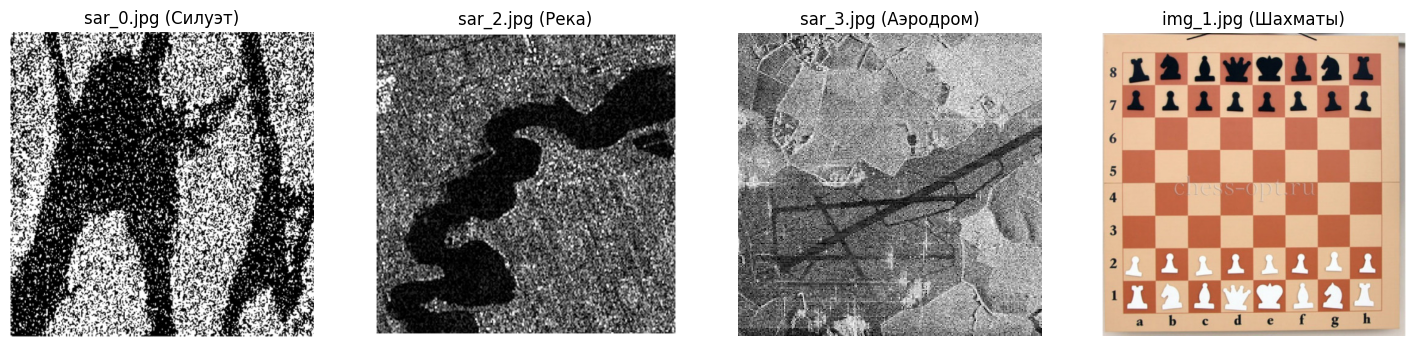

In [3]:
# Загрузка изображений
sar_0 = cv2.imread('sar_0.jpg')
sar_0_gray = cv2.cvtColor(sar_0, cv2.COLOR_BGR2GRAY) if sar_0 is not None else None

sar_2 = cv2.imread('sar_2.jpg')
sar_2_gray = cv2.cvtColor(sar_2, cv2.COLOR_BGR2GRAY) if sar_2 is not None else None

sar_3 = cv2.imread('sar_3.jpg')
sar_3_gray = cv2.cvtColor(sar_3, cv2.COLOR_BGR2GRAY) if sar_3 is not None else None

img_chess = cv2.imread('img_1.jpg')
img_chess_rgb = cv2.cvtColor(img_chess, cv2.COLOR_BGR2RGB) if img_chess is not None else None
img_chess_gray = cv2.cvtColor(img_chess, cv2.COLOR_BGR2GRAY) if img_chess is not None else None

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(sar_0_gray, cmap='gray')
axes[0].set_title('sar_0.jpg (Силуэт)')
axes[1].imshow(sar_2_gray, cmap='gray')
axes[1].set_title('sar_2.jpg (Река)')
axes[2].imshow(sar_3_gray, cmap='gray')
axes[2].set_title('sar_3.jpg (Аэродром)')
axes[3].imshow(img_chess_rgb)
axes[3].set_title('img_1.jpg (Шахматы)')
for ax in axes: ax.axis('off')
plt.show()

## 2. Глобальная бинаризация
Сравним фиксированный порог, метод последовательных приближений (итеративный поиск порога) и метод Оцу.

Порог последовательных приближений: 94.30
Порог методом Оцу: 93.00


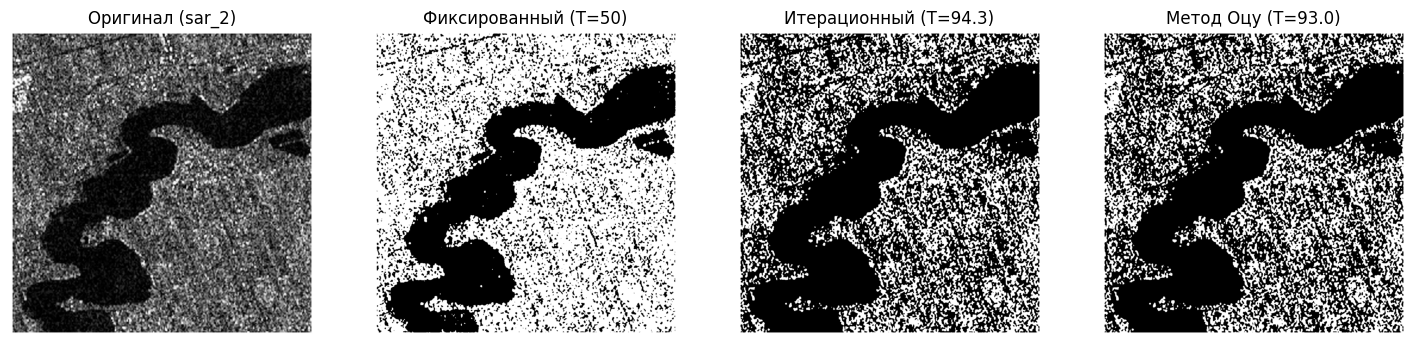

In [4]:
# 1. Фиксированный порог
T_fixed = 50
_, bin_fixed = cv2.threshold(sar_2_gray, T_fixed, 255, cv2.THRESH_BINARY)

# 2. Метод последовательных приближений
def iterative_threshold(image, epsilon=0.5):
    T = 128.0
    while True:
        m1 = image[image < T].mean() if np.any(image < T) else 0
        m2 = image[image >= T].mean() if np.any(image >= T) else 255
        T_new = (m1 + m2) / 2.0
        if abs(T - T_new) < epsilon:
            break
        T = T_new
    return T

T_iter = iterative_threshold(sar_2_gray)
_, bin_iter = cv2.threshold(sar_2_gray, T_iter, 255, cv2.THRESH_BINARY)

# 3. Метод Оцу
T_otsu, bin_otsu = cv2.threshold(sar_2_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print(f"Порог последовательных приближений: {T_iter:.2f}")
print(f"Порог методом Оцу: {T_otsu:.2f}")

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(sar_2_gray, cmap='gray')
axes[0].set_title('Оригинал (sar_2)')
axes[1].imshow(bin_fixed, cmap='gray')
axes[1].set_title(f'Фиксированный (T={T_fixed})')
axes[2].imshow(bin_iter, cmap='gray')
axes[2].set_title(f'Итерационный (T={T_iter:.1f})')
axes[3].imshow(bin_otsu, cmap='gray')
axes[3].set_title(f'Метод Оцу (T={T_otsu:.1f})')
for ax in axes: ax.axis('off')
plt.show()

## 3. Адаптивная бинаризация
Используем локальный расчет порога по скользящему окну окрестности (Adaptive Mean и Adaptive Gaussian).

In [ ]:
block_size = 71
C = 21

th_adapt_mean = cv2.adaptiveThreshold(sar_2_gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                     cv2.THRESH_BINARY, block_size, C)
th_adapt_gauss = cv2.adaptiveThreshold(sar_2_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                      cv2.THRESH_BINARY, block_size, C)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(bin_otsu, cmap='gray')
axes[0].set_title('Глобальный (Оцу)')
axes[1].imshow(th_adapt_mean, cmap='gray')
axes[1].set_title(f'Адаптивный Mean (R={block_size}, C={C})')
axes[2].imshow(th_adapt_gauss, cmap='gray')
axes[2].set_title(f'Адаптивный Gauss (R={block_size}, C={C})')
for ax in axes: ax.axis('off')
plt.show()

## 4. Очистка силуэта и морфологическое выделение границ на `sar_0.jpg`
Снимок `sar_0.jpg` содержит силуэт человека с выраженным зернистым шумом.
Сначала проведем фильтрацию мелкого шума морфологическими операциями (Opening/Closing), а затем выделим внутреннюю и внешнюю границы объекта.

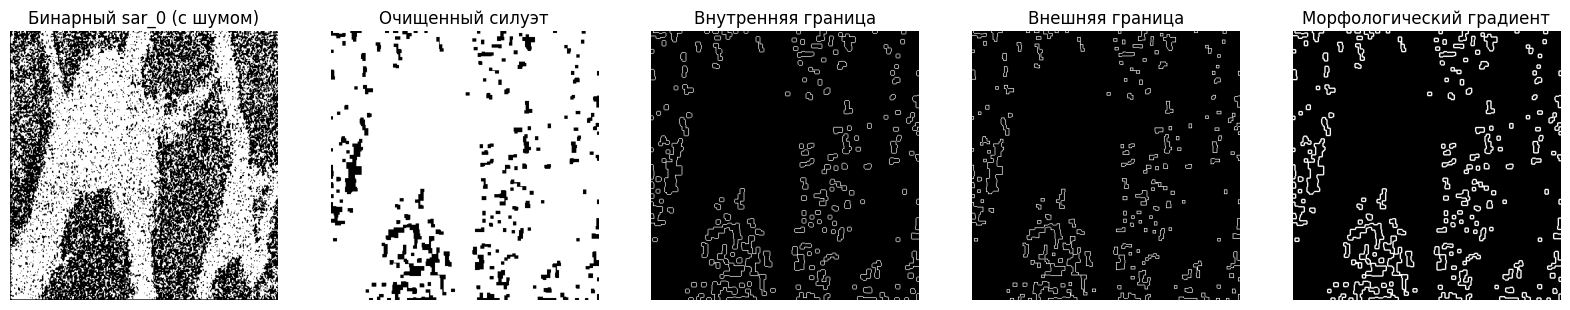

In [ ]:
# Бинаризация силуэта (инвертируем, чтобы силуэт был белым объектом)
_, sar_0_bin = cv2.threshold(sar_0_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Очистка шума с помощью Closing -> Opening
kernel_clean = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
sar_0_clean = cv2.morphologyEx(sar_0_bin, cv2.MORPH_CLOSE, kernel_clean)
sar_0_clean = cv2.morphologyEx(sar_0_clean, cv2.MORPH_OPEN, kernel_clean)

# Выделение границ структурным элементом 3х3
kernel_edge = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))
erosion = cv2.erode(sar_0_clean, kernel_edge, iterations=1)
dilation = cv2.dilate(sar_0_clean, kernel_edge, iterations=1)

# Границы:
internal_border = cv2.subtract(sar_0_clean, erosion)  # Внутренняя граница
external_border = cv2.subtract(dilation, sar_0_clean)  # Внешняя граница
morph_gradient = cv2.morphologyEx(sar_0_clean, cv2.MORPH_GRADIENT, kernel_edge)  # Градиент

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
axes[0].imshow(sar_0_bin, cmap='gray')
axes[0].set_title('Бинарный sar_0 (с шумом)')
axes[1].imshow(sar_0_clean, cmap='gray')
axes[1].set_title('Очищенный силуэт')
axes[2].imshow(internal_border, cmap='gray')
axes[2].set_title('Внутренняя граница')
axes[3].imshow(external_border, cmap='gray')
axes[3].set_title('Внешняя граница')
axes[4].imshow(morph_gradient, cmap='gray')
axes[4].set_title('Морфологический градиент')
for ax in axes: ax.axis('off')
plt.show()

## 5. Выделение границ на полутоновых изображениях (дифференциальные операторы и Кэнни)
Исследуем детекторы границ на снимке `sar_3.jpg` (Аэродром):
* Оператор Собеля;
* Лапласиан;
* Детектор границ Кэнни.

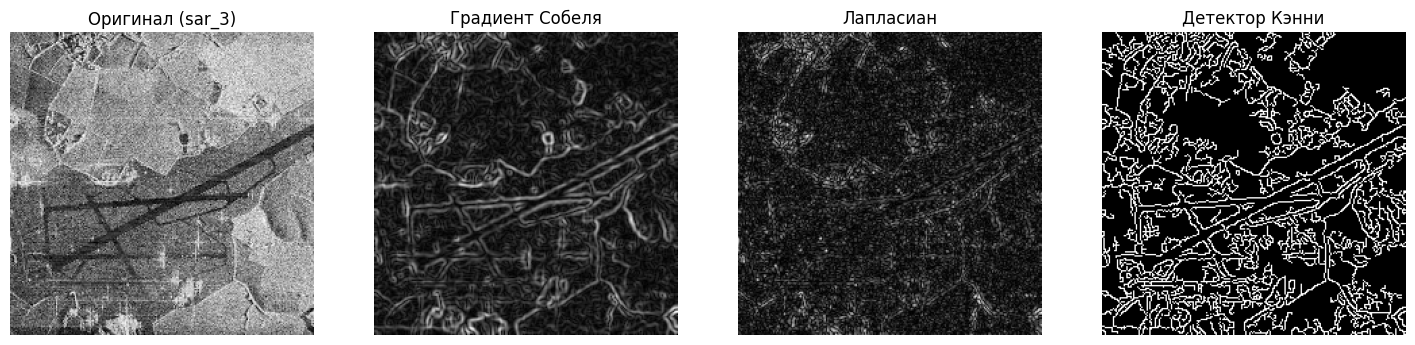

In [ ]:
# Предварительное сглаживание Гауссом для подавления спекл-шума
blur = cv2.GaussianBlur(sar_3_gray, (5, 5), 1.0)

# 1. Градиент Собеля
sobelx = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = np.hypot(sobelx, sobely)
sobel_mag = np.uint8(255 * sobel_mag / np.max(sobel_mag))

# 2. Лапласиан
laplacian = cv2.Laplacian(blur, cv2.CV_64F)
laplacian = np.uint8(np.absolute(laplacian))

# 3. Детектор Кэнни
canny_edges = cv2.Canny(blur, threshold1=50, threshold2=150)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(sar_3_gray, cmap='gray')
axes[0].set_title('Оригинал (sar_3)')
axes[1].imshow(sobel_mag, cmap='gray')
axes[1].set_title('Градиент Собеля')
axes[2].imshow(laplacian, cmap='gray')
axes[2].set_title('Лапласиан')
axes[3].imshow(canny_edges, cmap='gray')
axes[3].set_title('Детектор Кэнни')
for ax in axes: ax.axis('off')
plt.show()

## 6. Поиск прямых линий методом Хафа (Hough Transform)
Применим вероятностное преобразование Хафа для выделения координатной сетки шахматной доски (`img_1.jpg`) и взлетно-посадочных полос (`sar_3.jpg`).

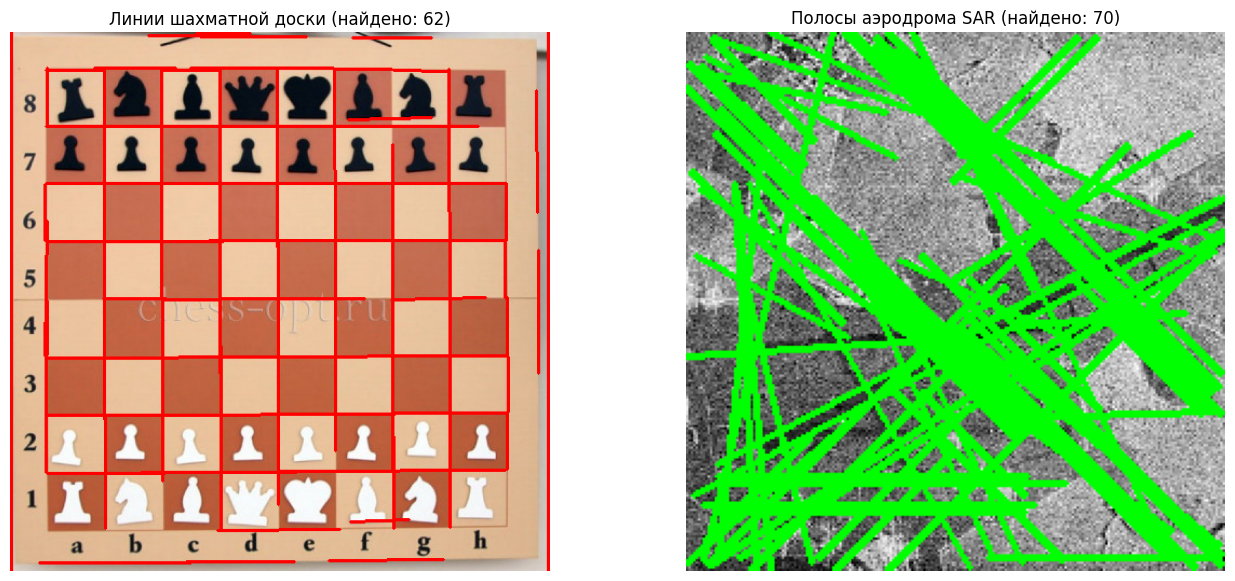

In [ ]:
# 1. Линии шахматной доски
chess_edges = cv2.Canny(img_chess_gray, 50, 150, apertureSize=3)
lines_chess = cv2.HoughLinesP(chess_edges, rho=1, theta=np.pi/180, threshold=80, minLineLength=50, maxLineGap=10)

img_lines_chess = img_chess_rgb.copy()
if lines_chess is not None:
    for line in lines_chess:
        x1, y1, x2, y2 = line[0]
        cv2.line(img_lines_chess, (x1, y1), (x2, y2), (255, 0, 0), 2)

# 2. Полосы аэродрома
lines_sar = cv2.HoughLinesP(canny_edges, rho=1, theta=np.pi/180, threshold=60, minLineLength=40, maxLineGap=15)

img_lines_sar = cv2.cvtColor(sar_3_gray, cv2.COLOR_GRAY2RGB)
if lines_sar is not None:
    for line in lines_sar:
        x1, y1, x2, y2 = line[0]
        cv2.line(img_lines_sar, (x1, y1), (x2, y2), (0, 255, 0), 2)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(img_lines_chess)
axes[0].set_title(f'Линии шахматной доски (найдено: {len(lines_chess) if lines_chess is not None else 0})')
axes[0].axis('off')

axes[1].imshow(img_lines_sar)
axes[1].set_title(f'Полосы аэродрома SAR (найдено: {len(lines_sar) if lines_sar is not None else 0})')
axes[1].axis('off')
plt.show()